In [1]:
# 1: Import Libraries and Set Random Seed: 
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                             classification_report, confusion_matrix, roc_auc_score)
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Imported successfully!")
print(f"Random seed set to: {RANDOM_SEED}")

Imported successfully!
Random seed set to: 42


In [2]:
# 2: Load and Prepare Dataset
df = pd.read_csv('C:\\Users\\MyMachine\\Desktop\\Fuzzy-Logic-Based-Maternal-Mental-Health-Risk-Assessment\\Feature_Engineering\\df_mat.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:\n{df['ppd_risk_level'].value_counts()}")

Dataset shape: (20000, 46)

Target distribution:
ppd_risk_level
0    8149
1    8092
2    3759
Name: count, dtype: int64


In [3]:
# First few rows of our dataset: 
df.head(5)

,age,education_level,wealth_index,monthly_household_income,food_security,housing_quality,financial_stress_level,parity,anc_visits,gestational_age,...,mental_health_awareness_Low,mental_health_awareness_Medium,residence,caste_discrimination_exposure,family_type,birth_complications,previous_pregnancy_loss,health_insurance,previous_mental_health_consultation,ppd_risk_level
0,21,Secondary,Richer,51044,Secure,9,0,0,8,40,...,0.0,1.0,1,0,1,0,0,1,1,0
1,38,Primary,Richer,39767,Moderately insecure,8,1,2,7,35,...,1.0,0.0,0,1,1,1,0,0,0,2
2,38,Secondary,Middle,45000,Mildly insecure,5,4,1,2,39,...,0.0,0.0,0,0,1,0,0,0,0,0
3,41,Secondary,Poorer,17768,Mildly insecure,4,6,0,6,38,...,0.0,1.0,0,0,0,0,0,0,0,0
4,43,Primary,Richer,61897,Secure,8,4,3,10,40,...,0.0,1.0,0,0,1,0,0,0,0,1


In [4]:
# 3: Define Fuzzy Membership Functions: 
def trap_mf(x, a, b, c, d):
    """Trapezoidal membership function"""
    return np.maximum(0, np.minimum(1, np.minimum((x - a) / (b - a + 1e-10), 
                                                    (d - x) / (d - c + 1e-10))))

def tri_mf(x, a, b, c):
    """Triangular membership function"""
    return np.maximum(0, np.minimum((x - a) / (b - a + 1e-10), 
                                     (c - x) / (c - b + 1e-10)))

print("Fuzzy membership functions defined!")

Fuzzy membership functions defined!


In [5]:
# 4: Define Fuzzification Functions for All Features:

def fuzzify_age(age_series, params):
    """Fuzzify age with optimizable parameter"""
    # params[0] = young_d (optimizable)
    young_d = params[0]
    
    mu_young = trap_mf(age_series, 16, 16, 22, young_d)
    mu_prime = tri_mf(age_series, 26, 30, 38)
    mu_advanced = trap_mf(age_series, 36, 40, 44, 44)
    
    return pd.DataFrame({
        'mu_age_young': mu_young,
        'mu_age_prime': mu_prime,
        'mu_age_advanced': mu_advanced
    })

def fuzzify_income(income_series, params):
    """Fuzzify monthly household income"""
    # params[0] = mod_b (optimizable)
    mod_b = params[0]
    
    mu_low = trap_mf(income_series, 8000, 20000, 20000, 45000)
    mu_mod = tri_mf(income_series, 30000, mod_b, 100000)
    mu_high = trap_mf(income_series, 80000, 120000, 180000, 180000)
    
    return pd.DataFrame({
        'mu_inc_low': mu_low,
        'mu_inc_mod': mu_mod,
        'mu_inc_high': mu_high
    })

def fuzzify_housing_quality(hq_series, params):
    """Fuzzify housing quality"""
    # params[0] = mod_b (optimizable)
    mod_b = params[0]
    
    mu_low = trap_mf(hq_series, 1.0, 3.0, 3.0, 6.0)
    mu_mod = tri_mf(hq_series, 4.0, mod_b, 8.0)
    mu_high = trap_mf(hq_series, 7.0, 9.0, 10.0, 10.0)
    
    return pd.DataFrame({
        'mu_hq_low': mu_low,
        'mu_hq_mod': mu_mod,
        'mu_hq_high': mu_high
    })

def fuzzify_financial_stress(stress_series, params):
    """Fuzzify financial stress level"""
    # params[0] = mod_b (optimizable)
    mod_b = params[0]
    
    mu_low = trap_mf(stress_series, 0.0, 2.0, 2.0, 4.0)
    mu_mod = tri_mf(stress_series, 3.0, mod_b, 7.0)
    mu_high = trap_mf(stress_series, 6.0, 8.0, 10.0, 10.0)
    
    return pd.DataFrame({
        'mu_stress_low': mu_low,
        'mu_stress_mod': mu_mod,
        'mu_stress_high': mu_high
    })

def fuzzify_parity(parity_series, params):
    """Fuzzify parity"""
    # params[0] = opt_b (optimizable)
    opt_b = params[0]
    
    mu_low = trap_mf(parity_series, 0.0, 1.0, 1.0, 3.0)
    mu_opt = tri_mf(parity_series, 1.0, opt_b, 4.0)
    mu_high = trap_mf(parity_series, 3.0, 5.0, 8.0, 8.0)
    
    return pd.DataFrame({
        'mu_parity_low': mu_low,
        'mu_parity_opt': mu_opt,
        'mu_parity_high': mu_high
    })

def fuzzify_anc_visits(anc_series, params):
    """Fuzzify ANC visits"""
    # params[0] = suff_b (optimizable)
    suff_b = params[0]
    
    mu_inad = trap_mf(anc_series, 0.0, 3.0, 3.0, 5.0)
    mu_suff = tri_mf(anc_series, 3.0, suff_b, 8.0)
    mu_opt = trap_mf(anc_series, 7.0, 9.0, 12.0, 12.0)
    
    return pd.DataFrame({
        'mu_anc_inadequate': mu_inad,
        'mu_anc_sufficient': mu_suff,
        'mu_anc_optimal': mu_opt
    })

def fuzzify_gestational_age(ga_series, params):
    """Fuzzify gestational age"""
    # params[0] = optimal_b (optimizable)
    opt_b = params[0]
    
    mu_preterm = trap_mf(ga_series, 29.0, 36.0, 36.0, 38.0)
    mu_optimal = trap_mf(ga_series, 37.0, opt_b, 41.0, 42.0)
    mu_late = trap_mf(ga_series, 40.0, 42.0, 42.0, 42.0)
    
    return pd.DataFrame({
        'mu_ga_preterm': mu_preterm,
        'mu_ga_optimal': mu_optimal,
        'mu_ga_late_post': mu_late
    })

def fuzzify_maternal_age_first_birth(age_series, params):
    """Fuzzify maternal age at first birth"""
    # params[0] = optimal_c (optimizable)
    opt_c = params[0]
    
    mu_early = trap_mf(age_series, 15.0, 19.0, 19.0, 22.0)
    mu_optimal = trap_mf(age_series, 20.0, 21.0, opt_c, 35.0)
    mu_advanced = trap_mf(age_series, 34.0, 35.0, 44.0, 44.0)
    
    return pd.DataFrame({
        'mu_maternal_age_early': mu_early,
        'mu_maternal_age_optimal': mu_optimal,
        'mu_maternal_age_advanced': mu_advanced
    })

def fuzzify_partner_support(support_series, params):
    """Fuzzify partner support score"""
    # params[0] = mod_b (optimizable)
    mod_b = params[0]
    
    mu_low = trap_mf(support_series, 0.0, 4.0, 4.0, 6.0)
    mu_mod = tri_mf(support_series, 4.0, mod_b, 8.0)
    mu_high = trap_mf(support_series, 7.0, 9.0, 10.0, 10.0)
    
    return pd.DataFrame({
        'mu_support_low': mu_low,
        'mu_support_mod': mu_mod,
        'mu_support_high': mu_high
    })

def fuzzify_family_support(support_series, params):
    """Fuzzify family support score"""
    # params[0] = mod_b (optimizable)
    mod_b = params[0]
    
    mu_inad = trap_mf(support_series, 0.0, 4.0, 4.0, 6.0)
    mu_mod = tri_mf(support_series, 4.0, mod_b, 8.0)
    mu_strong = trap_mf(support_series, 7.0, 9.0, 10.0, 10.0)
    
    return pd.DataFrame({
        'mu_family_inadequate': mu_inad,
        'mu_family_moderate': mu_mod,
        'mu_family_strong': mu_strong
    })

def fuzzify_social_isolation(iso_series, params):
    """Fuzzify social isolation score"""
    # params[0] = mod_b (optimizable)
    mod_b = params[0]
    
    mu_low = trap_mf(iso_series, 0.0, 2.0, 2.0, 4.0)
    mu_mod = tri_mf(iso_series, 3.0, mod_b, 7.0)
    mu_high = trap_mf(iso_series, 6.0, 8.0, 10.0, 10.0)
    
    return pd.DataFrame({
        'mu_isolation_low': mu_low,
        'mu_isolation_mod': mu_mod,
        'mu_isolation_high': mu_high
    })

def fuzzify_sleep_quality(sleep_series, params):
    """Fuzzify sleep quality"""
    # params[0] = mod_b (optimizable)
    mod_b = params[0]
    
    mu_poor = trap_mf(sleep_series, 1.0, 4.0, 4.0, 6.0)
    mu_mod = tri_mf(sleep_series, 4.0, mod_b, 8.0)
    mu_good = trap_mf(sleep_series, 7.0, 9.0, 10.0, 10.0)
    
    return pd.DataFrame({
        'mu_sleep_poor': mu_poor,
        'mu_sleep_moderate': mu_mod,
        'mu_sleep_good': mu_good
    })

def fuzzify_stressful_events(events_series, params):
    """Fuzzify stressful life events"""
    # params[0] = mod_b (optimizable)
    mod_b = params[0]
    
    mu_low = trap_mf(events_series, 0.0, 0.0, 0.0, 1.5)
    mu_mod = tri_mf(events_series, 0.5, mod_b, 3.5)
    mu_high = trap_mf(events_series, 3.0, 4.0, 5.0, 5.0)
    
    return pd.DataFrame({
        'mu_stress_low.1': mu_low,
        'mu_stress_mod.1': mu_mod,
        'mu_stress_high.1': mu_high
    })

def fuzzify_distance(dist_series, params):
    """Fuzzify distance to health facility"""
    # params[0] = mod_b (optimizable)
    mod_b = params[0]
    
    mu_easy = trap_mf(dist_series, 0.5, 2.0, 2.0, 5.0)
    mu_mod = tri_mf(dist_series, 3.0, mod_b, 10.0)
    mu_diff = trap_mf(dist_series, 8.0, 15.0, 50.0, 50.0)
    
    return pd.DataFrame({
        'mu_distance_easy': mu_easy,
        'mu_distance_moderate': mu_mod,
        'mu_distance_difficult': mu_diff
    })

def fuzzify_education(edu_series, params):
    """Fuzzify education level (discrete)"""
    # params = [primary_low, primary_med] (2 optimizable)
    fuzzy_map = {
        'No education': [1.0, 0.0, 0.0],
        'Primary': [params[0], params[1], 0.0],
        'Secondary': [0.2, 0.8, 0.0],
        'Higher': [0.0, 0.1, 0.9]
    }
    
    result = edu_series.map(lambda x: fuzzy_map.get(x, [0.33, 0.33, 0.34]))
    mu_df = pd.DataFrame(result.tolist(), columns=['mu_edu_low_risk', 'mu_edu_medium_risk', 'mu_edu_high_risk'])
    return mu_df

def fuzzify_wealth(wealth_series, params):
    """Fuzzify wealth index (discrete)"""
    # params = [poorer_high, poorer_med] (2 optimizable)
    fuzzy_map = {
        'Poorest': [1.0, 0.0, 0.0],
        'Poorer': [params[0], params[1], 0.0],
        'Middle': [0.3, 0.7, 0.0],
        'Richer': [0.0, 0.3, 0.7],
        'Richest': [0.0, 0.0, 1.0]
    }
    
    result = wealth_series.map(lambda x: fuzzy_map.get(x, [0.33, 0.33, 0.34]))
    mu_df = pd.DataFrame(result.tolist(), columns=['mu_wealth_high_poverty', 'mu_wealth_medium_wealth', 'mu_wealth_low_poverty'])
    return mu_df

def fuzzify_food_security(fs_series, params):
    """Fuzzify food security (discrete)"""
    # params = [mod_insec_high, mod_insec_mod] (2 optimizable)
    fuzzy_map = {
        'Severely insecure': [1.0, 0.0, 0.0],
        'Moderately insecure': [params[0], params[1], 0.0],
        'Mildly insecure': [0.3, 0.7, 0.0],
        'Secure': [0.0, 0.0, 1.0]
    }
    
    result = fs_series.map(lambda x: fuzzy_map.get(x, [0.33, 0.33, 0.34]))
    mu_df = pd.DataFrame(result.tolist(), columns=['mu_fs_high_risk', 'mu_fs_mod_risk', 'mu_fs_low_risk'])
    return mu_df

def fuzzify_domestic_violence(dv_series, params):
    """Fuzzify domestic violence exposure (discrete)"""
    # params = [sometimes_high, sometimes_mod] (2 optimizable)
    fuzzy_map = {
        'Often': [1.0, 0.0, 0.0],
        'Sometimes': [params[0], params[1], 0.0],
        'Rarely': [0.3, 0.7, 0.0],
        'Never': [0.0, 0.0, 1.0]
    }
    
    result = dv_series.map(lambda x: fuzzy_map.get(x, [0.33, 0.33, 0.34]))
    mu_df = pd.DataFrame(result.tolist(), columns=['mu_dv_high_risk', 'mu_dv_mod_risk', 'mu_dv_no_risk'])
    return mu_df

print("All fuzzification functions defined!")

All fuzzification functions defined!


In [6]:
# 5: Complete Fuzzification Pipeline: 

def apply_fuzzification(df, fuzzy_params):
    """
    Apply fuzzification to all features using given parameters
    
    fuzzy_params structure (22 total parameters):
    [0]: age_young_d
    [1]: income_mod_b
    [2]: housing_mod_b
    [3]: fin_stress_mod_b
    [4]: parity_opt_b
    [5]: anc_suff_b
    [6]: ga_optimal_b
    [7]: maternal_age_opt_c
    [8]: partner_support_mod_b
    [9]: family_support_mod_b
    [10]: isolation_mod_b
    [11]: sleep_mod_b
    [12]: stress_events_mod_b
    [13]: distance_mod_b
    [14-15]: edu_primary [low, med]
    [16-17]: wealth_poorer [high, med]
    [18-19]: food_mod_insec [high, mod]
    [20-21]: dv_sometimes [high, mod]
    """
    
    # Get crisp features (already encoded in df)
    crisp_cols = [
        'province_Gandaki', 'province_Karnali', 'province_Koshi',
        'province_Lumbini', 'province_Madhesh', 'province_Sudurpashchim',
        'ethnicity_Hill High Caste', 'ethnicity_Janajati', 'ethnicity_Muslim',
        'ethnicity_Terai Caste', 'occupation_Clerical', 'occupation_Manual',
        'occupation_Professional/Technical/Managerial',
        'occupation_Sales/Service', 'delivery_type_Cesarean',
        'delivery_type_Normal', 'baby_health_status_Major issues',
        'baby_health_status_Minor issues', 'mental_health_awareness_Low',
        'mental_health_awareness_Medium', 'residence',
        'caste_discrimination_exposure', 'family_type', 'birth_complications',
        'previous_pregnancy_loss', 'health_insurance',
        'previous_mental_health_consultation'
    ]
    
    # Start with crisp features and reset index
    result_df = df[crisp_cols].copy().reset_index(drop=True)
    
    # Collect all fuzzy features in a list
    fuzzy_dfs = []
    
    # Apply continuous fuzzification
    if 'age' in df.columns:
        fuzzy_dfs.append(fuzzify_age(df['age'].reset_index(drop=True), [fuzzy_params[0]]))
    
    if 'monthly_household_income' in df.columns:
        fuzzy_dfs.append(fuzzify_income(df['monthly_household_income'].reset_index(drop=True), [fuzzy_params[1]]))
    
    if 'housing_quality' in df.columns:
        fuzzy_dfs.append(fuzzify_housing_quality(df['housing_quality'].reset_index(drop=True), [fuzzy_params[2]]))
    
    if 'financial_stress_level' in df.columns:
        fuzzy_dfs.append(fuzzify_financial_stress(df['financial_stress_level'].reset_index(drop=True), [fuzzy_params[3]]))
    
    if 'parity' in df.columns:
        fuzzy_dfs.append(fuzzify_parity(df['parity'].reset_index(drop=True), [fuzzy_params[4]]))
    
    if 'anc_visits' in df.columns:
        fuzzy_dfs.append(fuzzify_anc_visits(df['anc_visits'].reset_index(drop=True), [fuzzy_params[5]]))
    
    if 'gestational_age' in df.columns:
        fuzzy_dfs.append(fuzzify_gestational_age(df['gestational_age'].reset_index(drop=True), [fuzzy_params[6]]))
    
    if 'maternal_age_at_first_birth' in df.columns:
        fuzzy_dfs.append(fuzzify_maternal_age_first_birth(df['maternal_age_at_first_birth'].reset_index(drop=True), [fuzzy_params[7]]))
    
    if 'partner_support_score' in df.columns:
        fuzzy_dfs.append(fuzzify_partner_support(df['partner_support_score'].reset_index(drop=True), [fuzzy_params[8]]))
    
    if 'family_support_score' in df.columns:
        fuzzy_dfs.append(fuzzify_family_support(df['family_support_score'].reset_index(drop=True), [fuzzy_params[9]]))
    
    if 'social_isolation_score' in df.columns:
        fuzzy_dfs.append(fuzzify_social_isolation(df['social_isolation_score'].reset_index(drop=True), [fuzzy_params[10]]))
    
    if 'sleep_quality' in df.columns:
        fuzzy_dfs.append(fuzzify_sleep_quality(df['sleep_quality'].reset_index(drop=True), [fuzzy_params[11]]))
    
    if 'stressful_life_events' in df.columns:
        fuzzy_dfs.append(fuzzify_stressful_events(df['stressful_life_events'].reset_index(drop=True), [fuzzy_params[12]]))
    
    if 'distance_to_health_facility' in df.columns:
        fuzzy_dfs.append(fuzzify_distance(df['distance_to_health_facility'].reset_index(drop=True), [fuzzy_params[13]]))
    
    # Apply discrete fuzzification
    if 'education_level' in df.columns:
        fuzzy_dfs.append(fuzzify_education(df['education_level'].reset_index(drop=True), fuzzy_params[14:16]))
    
    if 'wealth_index' in df.columns:
        fuzzy_dfs.append(fuzzify_wealth(df['wealth_index'].reset_index(drop=True), fuzzy_params[16:18]))
    
    if 'food_security' in df.columns:
        fuzzy_dfs.append(fuzzify_food_security(df['food_security'].reset_index(drop=True), fuzzy_params[18:20]))
    
    if 'domestic_violence_exposure' in df.columns:
        fuzzy_dfs.append(fuzzify_domestic_violence(df['domestic_violence_exposure'].reset_index(drop=True), fuzzy_params[20:22]))
    
    # Concatenate all at once
    if fuzzy_dfs:
        result_df = pd.concat([result_df] + fuzzy_dfs, axis=1)
    
    # Final safety check - ensure no index misalignment
    assert len(result_df) == len(df), f"Row count mismatch! Input: {len(df)}, Output: {len(result_df)}"
    
    return result_df

print("Complete fuzzification pipeline defined!")

Complete fuzzification pipeline defined!


In [7]:
# 6: Define Expert Parameters and Bounds

# Expert-defined initial parameters (22 parameters)
expert_params = np.array([
    28,      # age_young_d
    50000,   # income_mod_b
    6.0,     # housing_mod_b
    5.0,     # fin_stress_mod_b
    2.0,     # parity_opt_b
    5.0,     # anc_suff_b
    38.0,    # ga_optimal_b
    33.0,    # maternal_age_opt_c
    6.0,     # partner_support_mod_b
    6.0,     # family_support_mod_b
    4.5,     # isolation_mod_b
    6.5,     # sleep_mod_b
    2.0,     # stress_events_mod_b
    6.0,     # distance_mod_b
    0.7, 0.3,  # edu_primary [low, med]
    0.7, 0.3,  # wealth_poorer [high, med]
    0.8, 0.2,  # food_mod_insec [high, mod]
    0.9, 0.1   # dv_sometimes [high, mod]
])

# Define bounds for DE optimization
de_bounds = [
    (24, 32),           # age_young_d
    (40000, 60000),     # income_mod_b
    (5.0, 7.0),         # housing_mod_b
    (4.0, 6.0),         # fin_stress_mod_b
    (1.5, 2.5),         # parity_opt_b
    (4.0, 6.0),         # anc_suff_b
    (37.0, 39.0),       # ga_optimal_b
    (30.0, 35.0),       # maternal_age_opt_c
    (5.0, 7.0),         # partner_support_mod_b
    (5.0, 7.0),         # family_support_mod_b
    (4.0, 5.5),         # isolation_mod_b
    (5.5, 7.5),         # sleep_mod_b
    (1.5, 2.5),         # stress_events_mod_b
    (5.0, 7.0),         # distance_mod_b
    (0.5, 0.9), (0.1, 0.5),  # edu_primary
    (0.5, 0.9), (0.1, 0.5),  # wealth_poorer
    (0.6, 1.0), (0.0, 0.4),  # food_mod_insec
    (0.7, 1.0), (0.0, 0.3)   # dv_sometimes
]

print(f"Expert parameters defined: {len(expert_params)} parameters")
print(f"DE bounds defined: {len(de_bounds)} bounds")

Expert parameters defined: 22 parameters
DE bounds defined: 22 bounds


In [8]:
print(f"Expert parameters:\n{expert_params}")

Expert parameters:
[2.8e+01 5.0e+04 6.0e+00 5.0e+00 2.0e+00 5.0e+00 3.8e+01 3.3e+01 6.0e+00
 6.0e+00 4.5e+00 6.5e+00 2.0e+00 6.0e+00 7.0e-01 3.0e-01 7.0e-01 3.0e-01
 8.0e-01 2.0e-01 9.0e-01 1.0e-01]


In [9]:
# 7: Split Data and Create Baseline Dataset

# Split into train and test
X = df.drop('ppd_risk_level', axis=1)
y = df['ppd_risk_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set target distribution:\n{y_train.value_counts()}")

Training set size: 16000
Test set size: 4000

Training set target distribution:
ppd_risk_level
0    6519
1    6474
2    3007
Name: count, dtype: int64


In [10]:
# Create baseline fuzzified dataset using expert parameters:

# Applying expert fuzzification to training data: 
X_train_fuzzified_expert = apply_fuzzification(X_train, expert_params)
X_test_fuzzified_expert = apply_fuzzification(X_test, expert_params)

In [11]:
print(f"Fuzzified training set shape: {X_train_fuzzified_expert.shape}")
print(f"Fuzzified test set shape: {X_test_fuzzified_expert.shape}")

Fuzzified training set shape: (16000, 81)
Fuzzified test set shape: (4000, 81)


In [12]:
# 8: Train Baseline Random Forest Model

print("Training baseline Random Forest with expert parameters...")

baseline_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

baseline_rf.fit(X_train_fuzzified_expert, y_train)

print("Baseline model trained successfully!")

Training baseline Random Forest with expert parameters...
Baseline model trained successfully!


In [13]:
# 9: Evaluate Baseline Model

# Training performance
y_train_pred = baseline_rf.predict(X_train_fuzzified_expert)
train_acc = accuracy_score(y_train, y_train_pred)

# Test performance
y_test_pred = baseline_rf.predict(X_test_fuzzified_expert)
test_acc = accuracy_score(y_test, y_test_pred)

# Detailed metrics
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_test_pred, average='weighted'
)

print("="*60)
print("BASELINE MODEL PERFORMANCE (Expert Parameters)")
print("="*60)
print(f"\nTraining Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"\nWeighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-Score: {f1:.4f}")

BASELINE MODEL PERFORMANCE (Expert Parameters)

Training Accuracy: 0.9367
Test Accuracy: 0.8345

Weighted Precision: 0.8379
Weighted Recall: 0.8345
Weighted F1-Score: 0.8335


In [14]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1630
           1       0.77      0.85      0.81      1618
           2       0.85      0.67      0.75       752

    accuracy                           0.83      4000
   macro avg       0.84      0.81      0.82      4000
weighted avg       0.84      0.83      0.83      4000



In [15]:
# Confusion Matrix
cm_baseline = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm_baseline)


Confusion Matrix:
[[1463  167    0]
 [ 157 1370   91]
 [   0  247  505]]


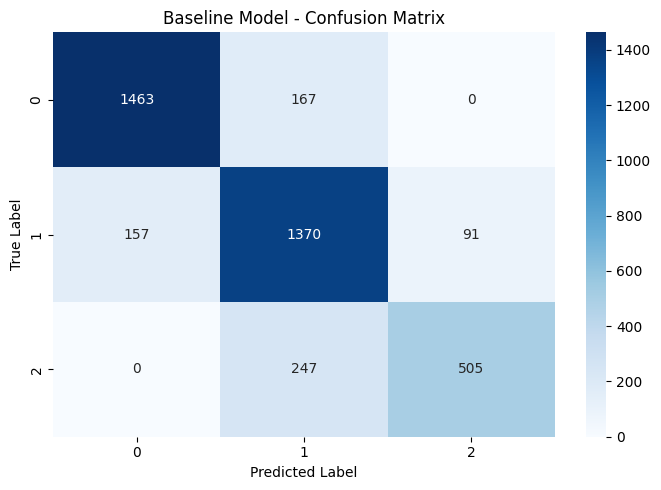

In [18]:
# Plot confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Top 15 Most Important Features:


,feature,importance
72,mu_wealth_high_poverty,0.084921
78,mu_dv_high_risk,0.083374
60,mu_sleep_poor,0.079904
51,mu_support_low,0.050421
62,mu_sleep_good,0.049358
80,mu_dv_no_risk,0.049211
38,mu_stress_high,0.039334
33,mu_hq_low,0.035544
61,mu_sleep_moderate,0.032433
79,mu_dv_mod_risk,0.032121


<Figure size 1000x800 with 0 Axes>

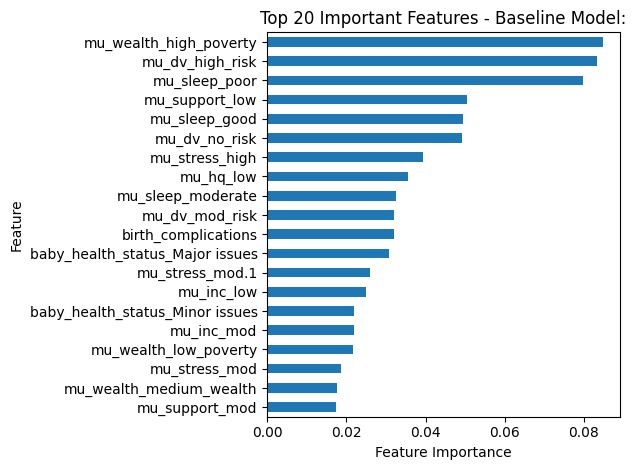

In [19]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_fuzzified_expert.columns,
    'importance': baseline_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
display(feature_importance.head(15))

# Plot feature importance
plt.figure(figsize=(10, 8))
feature_importance.head(20).plot(x='feature', y='importance', kind='barh', legend=False)
plt.title('Top 20 Important Features - Baseline Model:')
plt.xlabel('Feature Importance')
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# 10: Prepare Subset for DE Optimization

# Sample subset for DE optimization (2000 samples)
OPTIMIZATION_SIZE = min(2000, len(X_train))

# Stratified sampling
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, train_size=OPTIMIZATION_SIZE, random_state=RANDOM_SEED)

for opt_idx, _ in sss.split(X_train, y_train):
    X_train_opt = X_train.iloc[opt_idx].copy()
    y_train_opt = y_train.iloc[opt_idx].copy()

print(f"Optimization subset size: {len(X_train_opt)}")
print(f"Optimization subset target distribution:\n{y_train_opt.value_counts()}")

Optimization subset size: 2000
Optimization subset target distribution:
ppd_risk_level
0    815
1    809
2    376
Name: count, dtype: int64


In [ ]:
# 11: Define Objective Function for DE with Early Stopping

# Global variables for optimization
eval_counter = 0
best_score = 0
best_params_global = None
evals_without_improvement = 0
last_improvement_eval = 0
EVAL_PATIENCE = 100  # Stop after this many evaluations without improvement
MIN_IMPROVEMENT = 1e-6  # Minimum improvement to reset counter

def objective_function(fuzzy_params):
    """
    Objective function for Differential Evolution
    Minimizes: 1 - accuracy (so DE minimizes)
    With early stopping based on evaluation-level stagnation
    """
    global eval_counter, best_score, best_params_global
    global evals_without_improvement, last_improvement_eval
    
    eval_counter += 1
    
    # Check if we should stop early
    if evals_without_improvement >= EVAL_PATIENCE:
        # Return a dummy value but signal we should stop
        # The optimization will naturally conclude
        return 1 - best_score
    
    try:
        # Apply fuzzification with current parameters
        X_opt_fuzzified = apply_fuzzification(X_train_opt, fuzzy_params)
        
        # Train RF on subset
        rf_temp = RandomForestClassifier(
            n_estimators=50,  # Reduced for speed
            max_depth=10,
            min_samples_split=10,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        
        # Use cross-validation for robustness
        cv_scores = cross_val_score(
            rf_temp, X_opt_fuzzified, y_train_opt, 
            cv=3, scoring='accuracy', n_jobs=-1
        )
        
        score = cv_scores.mean()
        
        # Track best parameters and check for improvement
        if score > best_score + MIN_IMPROVEMENT:
            improvement = score - best_score
            best_score = score
            best_params_global = fuzzy_params.copy()
            evals_without_improvement = 0
            last_improvement_eval = eval_counter
            if eval_counter % 10 == 0 or eval_counter < 50:
                print(f"✓ Eval {eval_counter}: NEW BEST = {score:.6f} (improved by {improvement:.6f})")
        else:
            evals_without_improvement += 1
        
        # Print progress
        if eval_counter % 50 == 0:
            print(f"  Eval {eval_counter}: Current = {score:.4f}, Best = {best_score:.4f}, "
                  f"No improvement for {evals_without_improvement} evals")
        
        # Check for early stopping
        if evals_without_improvement >= EVAL_PATIENCE and eval_counter > 100:
            print(f"\n{'='*70}")
            print(f"EARLY STOPPING!")
            print(f"{'='*70}")
            print(f"No improvement for {EVAL_PATIENCE} consecutive evaluations")
            print(f"Last improvement at evaluation: {last_improvement_eval}")
            print(f"Best score achieved: {best_score:.6f}")
            print(f"Optimization will terminate gracefully...")
            print(f"{'='*70}\n")
        
        return 1 - score  # Minimize
        
    except Exception as e:
        print(f"Error in evaluation {eval_counter}: {str(e)}")
        evals_without_improvement += 1
        return 1.0  # Return worst score on error

print(f"Early stopping patience: {EVAL_PATIENCE} evaluations")
print(f"Minimum improvement threshold: {MIN_IMPROVEMENT}")

Objective function with early stopping defined!
Early stopping patience: 100 evaluations
Minimum improvement threshold: 1e-06
Ready for DE optimization...


In [ ]:
# 12: Run Differential Evolution Optimization

print("="*60)
print("STARTING DIFFERENTIAL EVOLUTION OPTIMIZATION")
print("="*60)
print(f"Population size: 15 (default)")
print(f"Max iterations: 20 (for computational efficiency)")
print(f"Parameters to optimize: {len(expert_params)}")
print(f"Optimization dataset size: {len(X_train_opt)}")
print("\nThis may take 10-30 minutes depending on the hardware...")
print("="*60)

# Reset counters
eval_counter = 0
best_score = 0

# Run DE optimization
result = differential_evolution(
    objective_function,
    bounds=de_bounds,
    maxiter=20,  # Limited for computational efficiency
    popsize=15,
    seed=RANDOM_SEED,
    workers=1,  # Serial to avoid memory issues
    updating='deferred',
    polish=True,
    atol=1e-4,
    tol=1e-4
)

optimized_params = result.x
optimized_score = 1 - result.fun

print("\n" + "="*60)
print("OPTIMIZATION COMPLETED!")
print("="*60)
print(f"Total evaluations: {eval_counter}")
print(f"Final optimized score: {optimized_score:.4f}")
print(f"Baseline score (expert): {train_acc:.4f}")
print(f"Improvement: {(optimized_score - train_acc)*100:.2f}%")

print("\n" + "="*60)
print("         OPTIMIZED PARAMETERS vs EXPERT PARAMETERS:")
print("="*60)

param_names = [
    'age_young_d', 'income_mod_b', 'housing_mod_b', 'fin_stress_mod_b',
    'parity_opt_b', 'anc_suff_b', 'ga_optimal_b', 'maternal_age_opt_c',
    'partner_support_mod_b', 'family_support_mod_b', 'isolation_mod_b',
    'sleep_mod_b', 'stress_events_mod_b', 'distance_mod_b',
    'edu_prim_low', 'edu_prim_med', 'wealth_poor_high', 'wealth_poor_med',
    'food_mod_high', 'food_mod_mod', 'dv_some_high', 'dv_some_mod'
]

comparison_df = pd.DataFrame({
    'Parameter': param_names,
    'Expert': expert_params,
    'Optimized': optimized_params,
    'Change': optimized_params - expert_params,
    'Change %': ((optimized_params - expert_params) / expert_params * 100)
})

print(comparison_df.to_string(index=False))

STARTING DIFFERENTIAL EVOLUTION OPTIMIZATION
Population size: 15 (default)
Max iterations: 20 (for computational efficiency)
Parameters to optimize: 22
Optimization dataset size: 2000

This may take 10-30 minutes depending on your hardware...
✓ Eval 1: NEW BEST = 0.767510 (improved by 0.767510)
✓ Eval 2: NEW BEST = 0.771504 (improved by 0.003994)
✓ Eval 11: NEW BEST = 0.772011 (improved by 0.000507)
✓ Eval 13: NEW BEST = 0.775003 (improved by 0.002992)
✓ Eval 14: NEW BEST = 0.780509 (improved by 0.005506)
  Eval 50: Current = 0.7750, Best = 0.7805, No improvement for 36 evals
  Eval 100: Current = 0.7610, Best = 0.7805, No improvement for 86 evals
  Eval 150: Current = 0.7725, Best = 0.7815, No improvement for 9 evals
  Eval 200: Current = 0.7705, Best = 0.7815, No improvement for 59 evals

⛔ EARLY STOPPING CRITERIA MET!
No improvement for 100 consecutive evaluations
Last improvement at evaluation: 141
Best score achieved: 0.781513
Optimization will terminate gracefully...


OPTIMIZATI

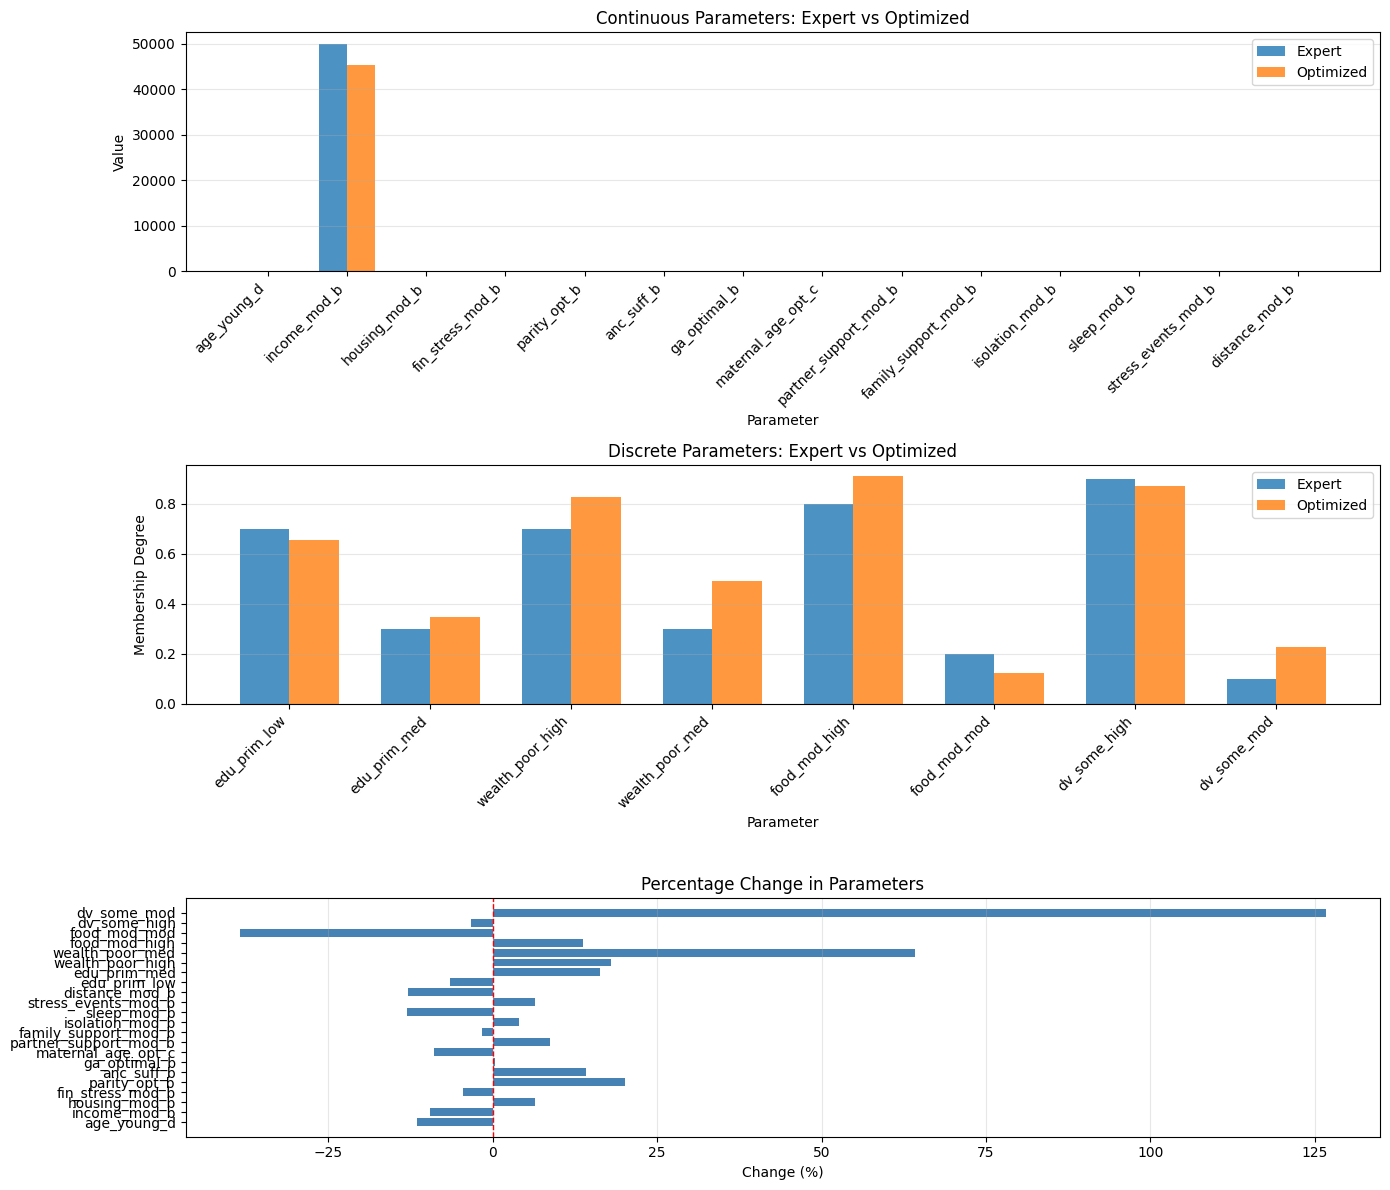

In [ ]:
# 13: Visualize Parameter Changes

# Plot parameter comparison
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Continuous parameters (0-13)
continuous_params = comparison_df.iloc[:14]
x = np.arange(len(continuous_params))
width = 0.35

axes[0].bar(x - width/2, continuous_params['Expert'], width, label='Expert', alpha=0.8)
axes[0].bar(x + width/2, continuous_params['Optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Parameter')
axes[0].set_ylabel('Value')
axes[0].set_title('Continuous Parameters: Expert vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels(continuous_params['Parameter'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Discrete parameters (14-21)
discrete_params = comparison_df.iloc[14:]
x2 = np.arange(len(discrete_params))

axes[1].bar(x2 - width/2, discrete_params['Expert'], width, label='Expert', alpha=0.8)
axes[1].bar(x2 + width/2, discrete_params['Optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Parameter')
axes[1].set_ylabel('Membership Degree')
axes[1].set_title('Discrete Parameters: Expert vs Optimized')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(discrete_params['Parameter'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Plot 3: Percentage change
axes[2].barh(comparison_df['Parameter'], comparison_df['Change %'], color='steelblue')
axes[2].set_xlabel('Change (%)')
axes[2].set_title('Percentage Change in Parameters')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 14: Train Final Optimized Model on Full Training Data

print("="*60)
print("TRAINING FINAL MODEL WITH OPTIMIZED PARAMETERS:")
print("="*60)

# Apply optimized fuzzification to full training data
print("Applying optimized fuzzification to full training set...")
X_train_fuzzified_opt = apply_fuzzification(X_train, optimized_params)
X_test_fuzzified_opt = apply_fuzzification(X_test, optimized_params)

print(f"Optimized training set shape: {X_train_fuzzified_opt.shape}")

# Train final optimized RF model
print("\nTraining optimized Random Forest...")
optimized_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

optimized_rf.fit(X_train_fuzzified_opt, y_train)

print("Optimized model trained successfully!")

TRAINING FINAL MODEL WITH OPTIMIZED PARAMETERS
Applying optimized fuzzification to full training set...
Optimized training set shape: (16000, 81)

Training optimized Random Forest...
Optimized model trained successfully!


OPTIMIZED MODEL PERFORMANCE

Training Accuracy: 0.9406
Test Accuracy: 0.8425

Weighted Precision: 0.8448
Weighted Recall: 0.8425
Weighted F1-Score: 0.8418

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90      1630
           1       0.78      0.84      0.81      1618
           2       0.86      0.70      0.77       752

    accuracy                           0.84      4000
   macro avg       0.85      0.82      0.83      4000
weighted avg       0.84      0.84      0.84      4000


Confusion Matrix:
[[1474  156    0]
 [ 165 1366   87]
 [   0  222  530]]


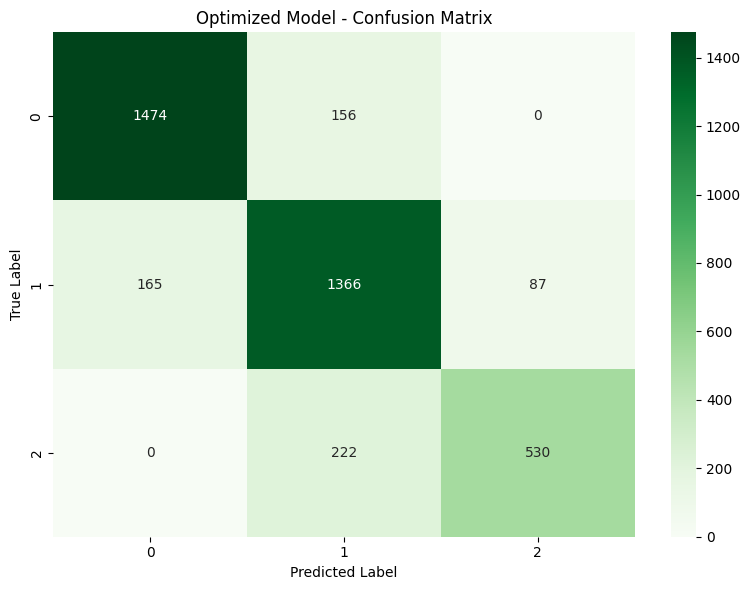

In [ ]:
# 15: Evaluate Optimized Model

# Training performance
y_train_pred_opt = optimized_rf.predict(X_train_fuzzified_opt)
train_acc_opt = accuracy_score(y_train, y_train_pred_opt)

# Test performance
y_test_pred_opt = optimized_rf.predict(X_test_fuzzified_opt)
test_acc_opt = accuracy_score(y_test, y_test_pred_opt)

# Detailed metrics
precision_opt, recall_opt, f1_opt, support_opt = precision_recall_fscore_support(
    y_test, y_test_pred_opt, average='weighted'
)

print("="*30)
print("OPTIMIZED MODEL PERFORMANCE")
print("="*30)
print(f"\nTraining Accuracy: {train_acc_opt:.4f}")
print(f"Test Accuracy: {test_acc_opt:.4f}")
print(f"\nWeighted Precision: {precision_opt:.4f}")
print(f"Weighted Recall: {recall_opt:.4f}")
print(f"Weighted F1-Score: {f1_opt:.4f}")

print("\n" + "="*60)
print("         Classification Report:")
print("="*60)
print(classification_report(y_test, y_test_pred_opt))

# Confusion Matrix
cm_optimized = confusion_matrix(y_test, y_test_pred_opt)
print("\nConfusion Matrix:")
print(cm_optimized)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens')
plt.title('Optimized Model - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

COMPREHENSIVE MODEL COMPARISON

           Metric  Baseline (Expert)  Optimized (DE)  Improvement  Improvement %
Training Accuracy           0.936750        0.940562     0.003812       0.406992
    Test Accuracy           0.834500        0.842500     0.008000       0.958658
        Precision           0.837934        0.844795     0.006861       0.818845
           Recall           0.834500        0.842500     0.008000       0.958658
         F1-Score           0.833524        0.841753     0.008229       0.987285


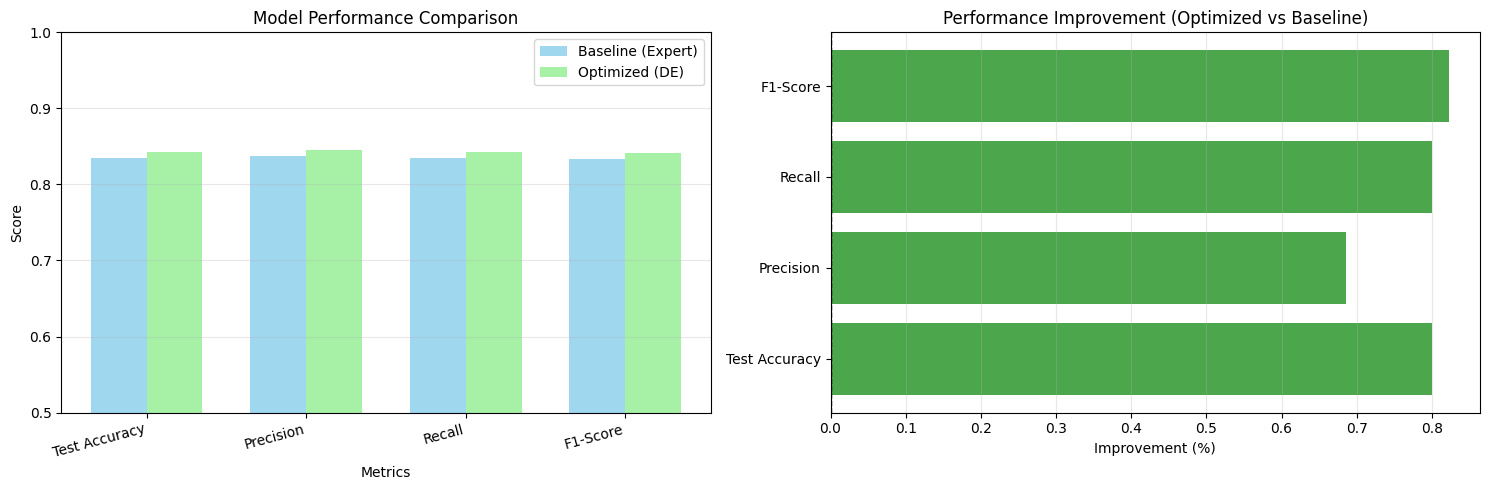

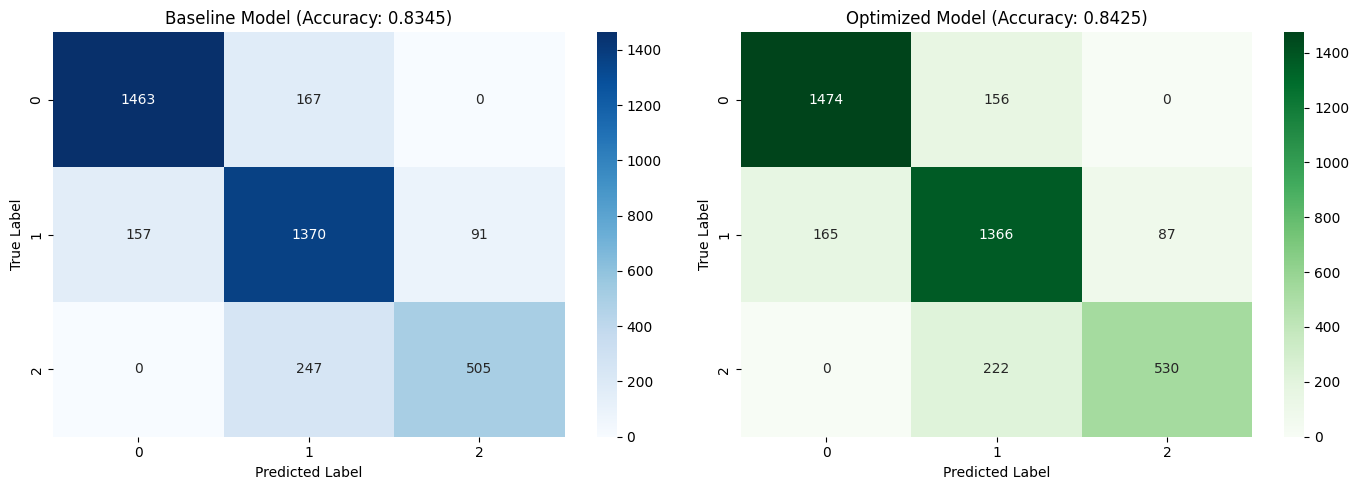

In [ ]:
# 16: Comprehensive Model Comparison

print("="*60)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*60)

# Create comparison dataframe
comparison_metrics = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Test Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline (Expert)': [train_acc, test_acc, precision, recall, f1],
    'Optimized (DE)': [train_acc_opt, test_acc_opt, precision_opt, recall_opt, f1_opt],
    'Improvement': [
        train_acc_opt - train_acc,
        test_acc_opt - test_acc,
        precision_opt - precision,
        recall_opt - recall,
        f1_opt - f1
    ],
    'Improvement %': [
        (train_acc_opt - train_acc) / train_acc * 100,
        (test_acc_opt - test_acc) / test_acc * 100,
        (precision_opt - precision) / precision * 100,
        (recall_opt - recall) / recall * 100,
        (f1_opt - f1) / f1 * 100
    ]
})

print("\n" + comparison_metrics.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart comparison
metrics_to_plot = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_values = [test_acc, precision, recall, f1]
optimized_values = [test_acc_opt, precision_opt, recall_opt, f1_opt]

x_pos = np.arange(len(metrics_to_plot))
width = 0.35

axes[0].bar(x_pos - width/2, baseline_values, width, label='Baseline (Expert)', alpha=0.8, color='skyblue')
axes[0].bar(x_pos + width/2, optimized_values, width, label='Optimized (DE)', alpha=0.8, color='lightgreen')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(metrics_to_plot, rotation=15, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.5, 1.0])

# Improvement visualization
improvements = [
    (test_acc_opt - test_acc) * 100,
    (precision_opt - precision) * 100,
    (recall_opt - recall) * 100,
    (f1_opt - f1) * 100
]

colors = ['green' if x > 0 else 'red' for x in improvements]
axes[1].barh(metrics_to_plot, improvements, color=colors, alpha=0.7)
axes[1].set_xlabel('Improvement (%)')
axes[1].set_title('Performance Improvement (Optimized vs Baseline)')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Baseline Model (Accuracy: {test_acc:.4f})')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Optimized Model (Accuracy: {test_acc_opt:.4f})')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

PER-CLASS PERFORMANCE COMPARISON

Class  Baseline Precision  Optimized Precision  Baseline Recall  Optimized Recall  Baseline F1  Optimized F1
    0            0.903086             0.899329         0.897546          0.904294     0.900308      0.901805
    1            0.767937             0.783257         0.846724          0.844252     0.805409      0.812612
    2            0.847315             0.858995         0.671543          0.704787     0.749258      0.774288


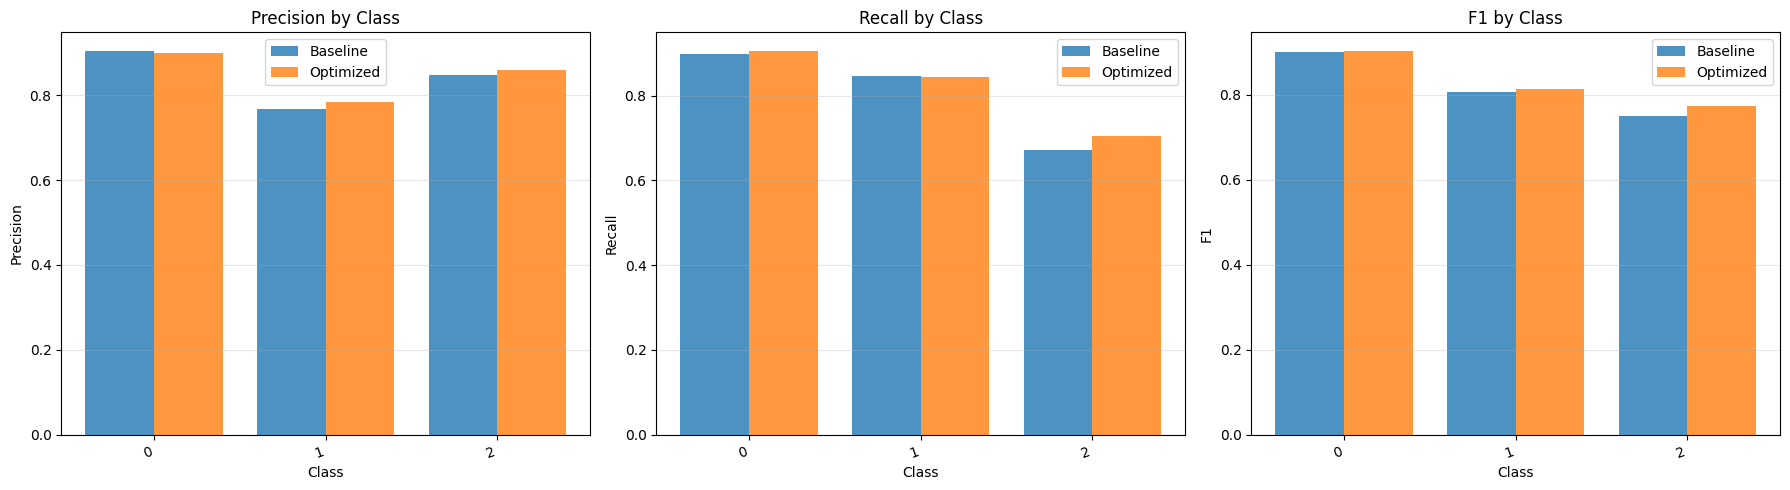

In [ ]:
# 17: Per-Class Performance Analysis

from sklearn.metrics import classification_report

print("="*60)
print("PER-CLASS PERFORMANCE COMPARISON")
print("="*60)

# Get class-wise metrics
baseline_report = classification_report(y_test, y_test_pred, output_dict=True)
optimized_report = classification_report(y_test, y_test_pred_opt, output_dict=True)

# Extract class names (excluding averages)
class_names = [k for k in baseline_report.keys() if k not in ['accuracy', 'macro avg', 'weighted avg']]

# Create detailed comparison
per_class_comparison = []
for class_name in class_names:
    per_class_comparison.append({
        'Class': class_name,
        'Baseline Precision': baseline_report[class_name]['precision'],
        'Optimized Precision': optimized_report[class_name]['precision'],
        'Baseline Recall': baseline_report[class_name]['recall'],
        'Optimized Recall': optimized_report[class_name]['recall'],
        'Baseline F1': baseline_report[class_name]['f1-score'],
        'Optimized F1': optimized_report[class_name]['f1-score']
    })

per_class_df = pd.DataFrame(per_class_comparison)
print("\n" + per_class_df.to_string(index=False))

# Visualize per-class performance
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Precision', 'Recall', 'F1']
for idx, metric in enumerate(metrics):
    baseline_col = f'Baseline {metric}'
    optimized_col = f'Optimized {metric}'
    
    x_pos = np.arange(len(class_names))
    axes[idx].bar(x_pos - 0.2, per_class_df[baseline_col], 0.4, label='Baseline', alpha=0.8)
    axes[idx].bar(x_pos + 0.2, per_class_df[optimized_col], 0.4, label='Optimized', alpha=0.8)
    axes[idx].set_xlabel('Class')
    axes[idx].set_ylabel(metric)
    axes[idx].set_title(f'{metric} by Class')
    axes[idx].set_xticks(x_pos)
    axes[idx].set_xticklabels(class_names, rotation=20, ha='right')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

TOP 20 FEATURE IMPORTANCES COMPARISON

                        feature  importance_baseline  importance_optimized    change
         mu_wealth_high_poverty             0.084921              0.086153  0.001232
                  mu_sleep_poor             0.079904              0.079947  0.000043
                mu_dv_high_risk             0.083374              0.079147 -0.004227
                  mu_dv_no_risk             0.049211              0.051511  0.002300
                 mu_support_low             0.050421              0.049913 -0.000508
                  mu_sleep_good             0.049358              0.047637 -0.001721
                 mu_stress_high             0.039334              0.038192 -0.001142
                      mu_hq_low             0.035544              0.033145 -0.002399
              mu_sleep_moderate             0.032433              0.033034  0.000601
baby_health_status_Major issues             0.030706              0.032490  0.001783
                 mu_dv_mod

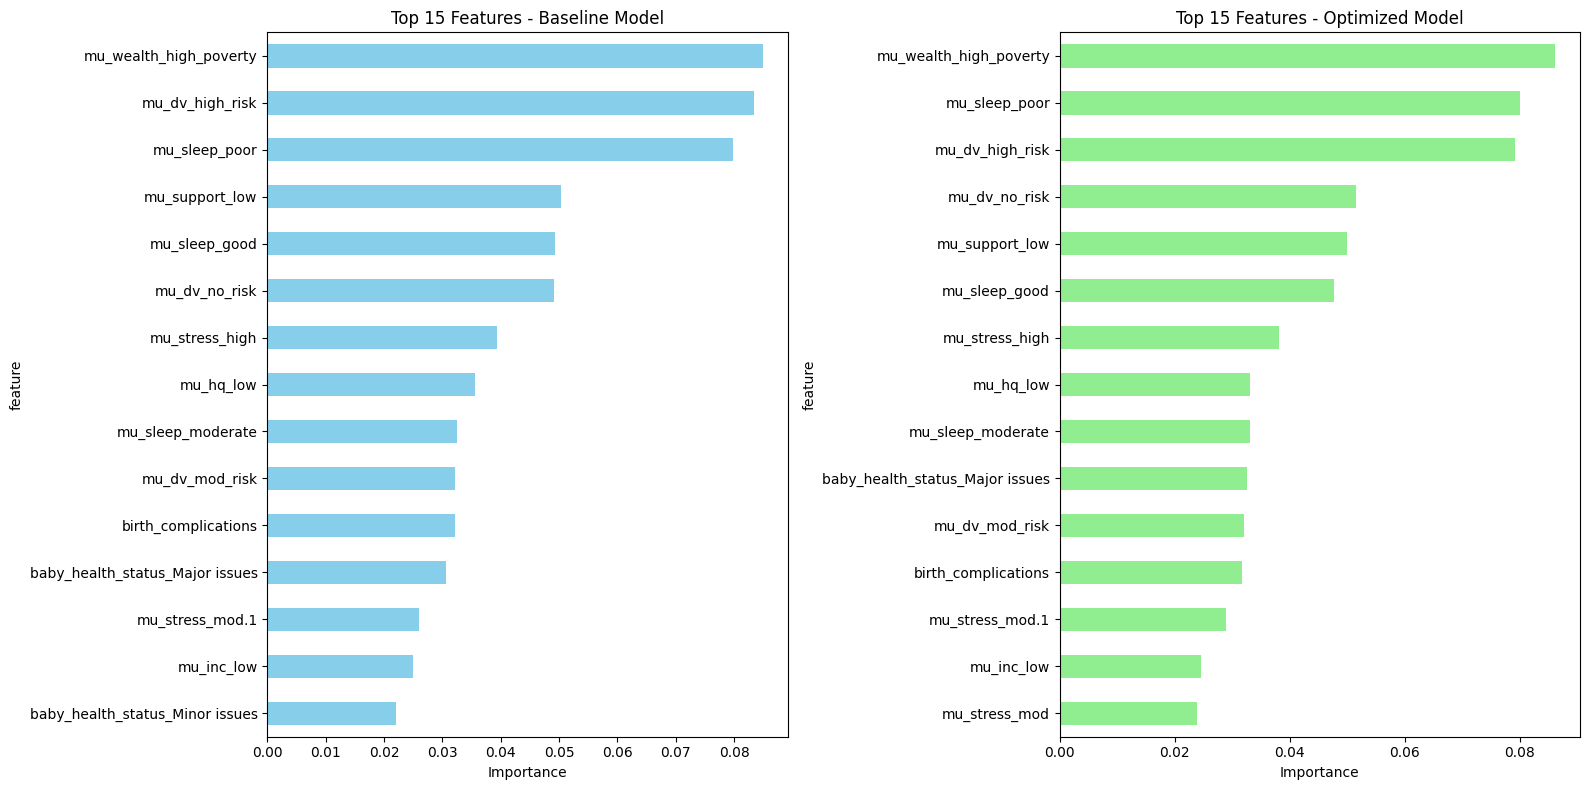

In [ ]:
# 18: Feature Importance Comparison

# Get feature importances from both models
baseline_importance = pd.DataFrame({
    'feature': X_train_fuzzified_expert.columns,
    'importance': baseline_rf.feature_importances_
}).sort_values('importance', ascending=False)

optimized_importance = pd.DataFrame({
    'feature': X_train_fuzzified_opt.columns,
    'importance': optimized_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("="*60)
print("TOP 20 FEATURE IMPORTANCES COMPARISON")
print("="*60)

# Merge for comparison
importance_comparison = baseline_importance.merge(
    optimized_importance, on='feature', suffixes=('_baseline', '_optimized')
)
importance_comparison['change'] = (
    importance_comparison['importance_optimized'] - importance_comparison['importance_baseline']
)
importance_comparison = importance_comparison.sort_values('importance_optimized', ascending=False)

print("\n" + importance_comparison.head(20).to_string(index=False))

# Plot top features side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Baseline top 15
baseline_importance.head(15).sort_values('importance').plot(
    x='feature', y='importance', kind='barh', ax=axes[0], legend=False, color='skyblue'
)
axes[0].set_title('Top 15 Features - Baseline Model')
axes[0].set_xlabel('Importance')

# Optimized top 15
optimized_importance.head(15).sort_values('importance').plot(
    x='feature', y='importance', kind='barh', ax=axes[1], legend=False, color='lightgreen'
)
axes[1].set_title('Top 15 Features - Optimized Model')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

In [ ]:
# 19: Save Models and Parameters

import joblib
import json

print("="*60)
print("SAVING MODELS AND PARAMETERS")
print("="*60)

# Save baseline model
joblib.dump(baseline_rf, 'baseline_rf_model.pkl')
print("✓ Baseline model saved: baseline_rf_model.pkl")

# Save optimized model
joblib.dump(optimized_rf, 'optimized_rf_model.pkl')
print("✓ Optimized model saved: optimized_rf_model.pkl")

# Save parameters
params_dict = {
    'expert_parameters': expert_params.tolist(),
    'optimized_parameters': optimized_params.tolist(),
    'parameter_names': param_names,
    'de_bounds': de_bounds
}

with open('fuzzy_parameters.json', 'w') as f:
    json.dump(params_dict, f, indent=2)
print("✓ Parameters saved: fuzzy_parameters.json")

# Save performance metrics
performance_dict = {
    'baseline': {
        'train_accuracy': float(train_acc),
        'test_accuracy': float(test_acc),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1)
    },
    'optimized': {
        'train_accuracy': float(train_acc_opt),
        'test_accuracy': float(test_acc_opt),
        'precision': float(precision_opt),
        'recall': float(recall_opt),
        'f1_score': float(f1_opt)
    },
    'improvements': {
        'test_accuracy': float(test_acc_opt - test_acc),
        'precision': float(precision_opt - precision),
        'recall': float(recall_opt - recall),
        'f1_score': float(f1_opt - f1)
    }
}

with open('model_performance.json', 'w') as f:
    json.dump(performance_dict, f, indent=2)
print("✓ Performance metrics saved: model_performance.json")

# Save comparison dataframes
comparison_metrics.to_csv('metrics_comparison.csv', index=False)
print("✓ Metrics comparison saved: metrics_comparison.csv")

comparison_df.to_csv('parameters_comparison.csv', index=False)
print("✓ Parameters comparison saved: parameters_comparison.csv")

per_class_df.to_csv('per_class_comparison.csv', index=False)
print("✓ Per-class comparison saved: per_class_comparison.csv")

In [ ]:
# 20: Final Summary Report

print("\n" + "="*80)
print(" "*25 + "FINAL OPTIMIZATION SUMMARY:")
print("="*80)

print(f"\n{'Dataset Statistics':<40}")
print(f"{'─'*80}")
print(f"  Total samples: {len(df):>10,}")
print(f"  Training samples: {len(X_train):>10,}")
print(f"  Test samples: {len(X_test):>10,}")
print(f"  Optimization subset: {OPTIMIZATION_SIZE:>10,}")
print(f"  Number of features (after fuzzification): {X_train_fuzzified_opt.shape[1]:>10}")

print(f"\n{'Optimization Process':<40}")
print(f"{'─'*80}")
print(f"  Parameters optimized: {len(optimized_params):>10}")
print(f"  DE iterations: {20:>10}")
print(f"  Total function evaluations: {eval_counter:>10,}")

print(f"\n{'Performance Improvements':<40}")
print(f"{'─'*80}")
print(f"  Test Accuracy:    {test_acc:.4f} → {test_acc_opt:.4f}  "
      f"({(test_acc_opt-test_acc)*100:+.2f}%)")
print(f"  Precision:        {precision:.4f} → {precision_opt:.4f}  "
      f"({(precision_opt-precision)*100:+.2f}%)")
print(f"  Recall:           {recall:.4f} → {recall_opt:.4f}  "
      f"({(recall_opt-recall)*100:+.2f}%)")
print(f"  F1-Score:         {f1:.4f} → {f1_opt:.4f}  "
      f"({(f1_opt-f1)*100:+.2f}%)")

print(f"\n{'Key Parameter Changes':<40}")
print(f"{'─'*80}")

# Show most changed parameters
top_changes = comparison_df.nlargest(5, 'Change %')[['Parameter', 'Change %']]
for _, row in top_changes.iterrows():
    print(f"  {row['Parameter']:<35} {row['Change %']:>+8.2f}%")

print(f"\n{'Saved Outputs':<40}")
print(f"{'─'*80}")
print(f"  ✓ baseline_rf_model.pkl")
print(f"  ✓ optimized_rf_model.pkl")
print(f"  ✓ fuzzy_parameters.json")
print(f"  ✓ model_performance.json")
print(f"  ✓ metrics_comparison.csv")
print(f"  ✓ parameters_comparison.csv")
print(f"  ✓ per_class_comparison.csv")

print("\n" + "="*80)
print(" "*20 + "OPTIMIZATION COMPLETED SUCCESSFULLY!")
print("="*80)

# Calculate and display if optimization was beneficial
if test_acc_opt > test_acc:
    print(f"\n✓ The optimized model shows IMPROVEMENT over the baseline.")
    print(f"  Recommendation: Use the optimized model for deployment.")
elif abs(test_acc_opt - test_acc) < 0.001:
    print(f"\n≈ The optimized model shows SIMILAR performance to baseline.")
    print(f"  Recommendation: Either model can be used; expert knowledge validated.")
else:
    print(f"\n✗ The optimized model shows SLIGHT DEGRADATION from baseline.")
    print(f"  Recommendation: Consider using baseline or investigating further.")